# Inter-subject RSI variation

RSI variation and its spatial association with principle functional gradient and myelin.

In [1]:
from pathlib import Path
import warnings

import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from neuromaps.nulls import alexander_bloch
from scipy.stats import pearsonr, zscore

warnings.filterwarnings('ignore')
project_root = Path('../..').resolve()
evaluation_dir = project_root / 'analysis' / 'evaluation'
from rise import (
    fetch_fine_grained_geodesic_distances,
    fetch_fine_grained_surface,
)
from rise.surface_plot import visualize_parcel_surface_map

font_path = project_root / 'font' / 'Whitney-Medium.otf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'


## Load RSI and precomputed maps

In [2]:
rsi_path = project_root / 'results' / 'rsi' / 'HCP' / 'test_rsi.csv'
hcp_info_path = project_root / 'data' / 'HCP' / 'info' / 'hcp_998.csv'

test_rsi = pd.read_csv(rsi_path)
subject_ids = test_rsi.iloc[:, 0].astype(str)
data = test_rsi[[f'r{i}' for i in range(7340)]].to_numpy(dtype=np.float32)

hcp_info = pd.read_csv(hcp_info_path)
hcp_info['Subject'] = hcp_info['Subject'].astype(str)
hcp_info = hcp_info.set_index('Subject').reindex(subject_ids)

confounds = pd.DataFrame(
    {
        'age': hcp_info['Age_in_Yrs'].to_numpy(dtype=float),
        'sex': hcp_info['Gender'].map({'M': 1, 'F': -1}).to_numpy(dtype=float),
    },
    index=subject_ids,
)
if confounds.isna().any().any():
    missing_ids = confounds.index[confounds.isna().any(axis=1)].tolist()
    raise ValueError(f'Missing age or sex for subjects: {missing_ids[:10]}')

grad1 = np.load(evaluation_dir / 'grad1.npy').reshape(-1)
myelin = np.load(evaluation_dir / 'myelin.npy').reshape(-1)

if data.shape[1] != 7340 or grad1.shape != (7340,) or myelin.shape != (7340,):
    raise ValueError(f'Unexpected shapes: RSI={data.shape}, gradient={grad1.shape}, myelin={myelin.shape}')
print(f'Test RSI shape: {data.shape}')

Test RSI shape: (708, 7340)


## RSI variation map

In [3]:
geodist_path = fetch_fine_grained_geodesic_distances()
geodist_df = pd.read_csv(geodist_path, index_col=0)
geodist_matrix = geodist_df.to_numpy(dtype=np.float32)
np.fill_diagonal(geodist_matrix, np.inf)

dense_name_list = geodist_df.columns.tolist()
n_parcels_per_hemi = len(dense_name_list) // 2 
neighbour_num = 4
nearest_neighbors = {}

for idx, row in enumerate(geodist_matrix[0:n_parcels_per_hemi, 0:n_parcels_per_hemi]):
    nearest_idx = np.argsort(row)[:neighbour_num]
    nearest_dist = row[nearest_idx]
    nearest_neighbors[dense_name_list[idx]] = {
        'neighbor_indices': nearest_idx,
        'distances': nearest_dist,
    }

for idx, row in enumerate(geodist_matrix[n_parcels_per_hemi:, n_parcels_per_hemi:]):
    nearest_idx = np.argsort(row)[:neighbour_num]
    nearest_dist = row[nearest_idx]
    nearest_neighbors[dense_name_list[idx + n_parcels_per_hemi]] = {
        'neighbor_indices': nearest_idx + n_parcels_per_hemi,
        'distances': nearest_dist,
    }

def smooth_array(group_average_fv, nearest_neighbors, sample_name_list, method='gaussian', sigma=4):
    smoothed = np.zeros_like(group_average_fv, dtype=np.float32)

    for i in range(len(group_average_fv)):
        region_name = sample_name_list[i]
        neighbor_info = nearest_neighbors[region_name]
        neighbor_indices = neighbor_info['neighbor_indices']
        neighbor_distances = neighbor_info['distances']

        all_indices = np.append(neighbor_indices, i)
        all_distances = np.append(neighbor_distances, 0.0)
        all_values = group_average_fv[all_indices]

        if method == 'gaussian':
            weights = np.exp(-(all_distances ** 2) / (2 * sigma ** 2))
            weights = weights / np.sum(weights)
            smoothed[i] = np.sum(all_values * weights)
        elif method == 'mean':
            smoothed[i] = np.mean(all_values)
        else:
            raise ValueError("method must be 'gaussian' or 'mean'")

    return smoothed


In [4]:
def regress_covariates(features, confounds):
    '''Regress covariates.'''
    features = np.asarray(features, dtype=float)
    confounds = np.asarray(confounds, dtype=float)

    design = np.column_stack([confounds, np.ones(confounds.shape[0])])
    coefficients, _, _, _ = np.linalg.lstsq(design, features, rcond=None)

    # Match the original workflow: retain the intercept while removing
    # contributions from age and sex.
    residuals = features - confounds @ coefficients[:-1]

    feature_min = features.min(axis=0)
    feature_range = features.max(axis=0) - feature_min
    residual_min = residuals.min(axis=0)
    residual_range = residuals.max(axis=0) - residual_min

    result = features.copy()
    scalable = (feature_range > 0) & (residual_range > 0)
    result[:, scalable] = (
        (residuals[:, scalable] - residual_min[scalable])
        / residual_range[scalable]
        * feature_range[scalable]
        + feature_min[scalable]
    )
    return result


group_mean = np.mean(data, axis=0)
if np.any(group_mean == 0):
    raise ValueError('Group-mean RSI contains zero-valued parcels.')

rsi_norm = data / group_mean
rsi_reg = regress_covariates(rsi_norm, confounds.to_numpy())
group_var = np.var(rsi_reg, axis=0)

In [5]:
# Smooth for visualization
group_var_smooth = smooth_array(
    group_average_fv=group_var,
    nearest_neighbors=nearest_neighbors,
    sample_name_list=dense_name_list,
    method='gaussian',
    sigma=4,
)

group_var_smooth_zs = zscore(group_var_smooth)

group_var_zs = zscore(group_var)
grad1_zs = zscore(grad1)
myelin_zs = zscore(myelin)

## Surface visualization

In [6]:
def set_cmap_saturation(cmap_name, saturation_factor):
    cmap = plt.get_cmap(cmap_name) if isinstance(cmap_name, str) else cmap_name
    rgba = cmap(np.linspace(0, 1, 256))
    hsv = mcolors.rgb_to_hsv(rgba[:, :3])
    hsv[:, 1] = np.clip(hsv[:, 1] * saturation_factor, 0, 1)
    rgba[:, :3] = mcolors.hsv_to_rgb(hsv)
    return mcolors.ListedColormap(rgba, name=f'{cmap.name}_sat_{saturation_factor}')


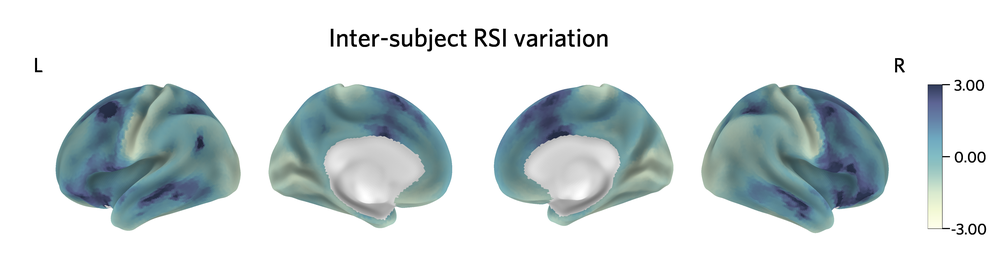

<Figure size 640x480 with 0 Axes>

In [7]:
visualize_parcel_surface_map(
    group_var_smooth_zs,
    title='Inter-subject RSI variation',
    cmap=set_cmap_saturation('YlGnBu', 0.5),
    max_value=3,
)


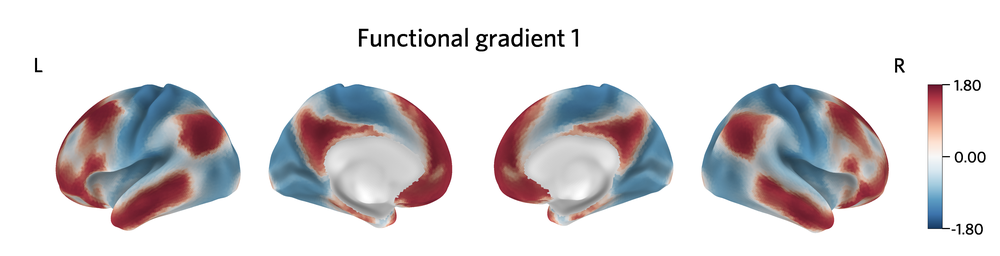

<Figure size 640x480 with 0 Axes>

In [8]:
visualize_parcel_surface_map(
    grad1_zs,
    title='Functional gradient 1',
    cmap=set_cmap_saturation('RdBu_r', 0.8),
    max_value=1.8,
)


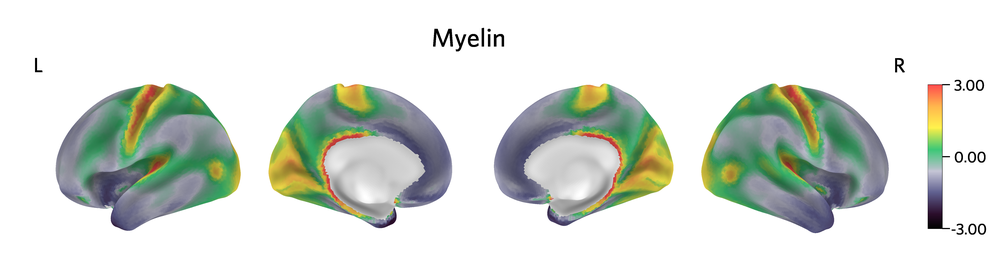

<Figure size 640x480 with 0 Axes>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def create_hcp_colormap():
    colors = [
        (0.0,  '#000000'), 
        (0.1,  '#2b002b'),  
        (0.25, '#4b4b8f'), 
        (0.4,  '#bfbfd6'),  
        (0.55, '#00c853'), 
        (0.7,  '#ffee00'), 
        (0.85, '#ff9800'), 
        (1.0,  '#ff0000'),
    ]
    return LinearSegmentedColormap.from_list("hcp_myelin", colors)

myelin_cmap = create_hcp_colormap()


visualize_parcel_surface_map(
    myelin_zs,
    title='Myelin',
    cmap=set_cmap_saturation(myelin_cmap, 0.7),
    max_value=3,
)

## Spin-test correlations

In [12]:
from PIL import Image
from IPython.display import display
from nilearn.surface import load_surf_data
lh_label_path, rh_label_path = fetch_fine_grained_surface(
    space='fs_LR', density='32k'
)
lh_lr32k_lab = load_surf_data(lh_label_path)
rh_lr32k_lab = load_surf_data(rh_label_path)

parcellation = (str(lh_label_path), str(rh_label_path))

def calculate_spin_correlation(map1, map2, parcellation, atlas='fsLR', density='32k', n_perm=5000, seed=42):
    map1 = np.asarray(map1).ravel()
    map2 = np.asarray(map2).ravel()
    if map1.shape != map2.shape:
        raise ValueError('map1 and map2 must have the same shape')
    map2_nulls = alexander_bloch(
        data=map2, atlas=atlas, density=density,
        parcellation=parcellation, n_perm=n_perm, seed=seed,
    )
    r_obs, _ = pearsonr(map1, map2)
    r_null = np.asarray([pearsonr(map1, map2_nulls[:, i])[0] for i in range(n_perm)])
    p_spin = (np.sum(np.abs(r_null) >= np.abs(r_obs)) + 1) / (n_perm + 1)
    return r_obs, p_spin, r_null

r_gradient, p_gradient, r_null_gradient = calculate_spin_correlation(grad1_zs, group_var_zs, parcellation)
r_myelin, p_myelin, r_null_myelin = calculate_spin_correlation(myelin_zs, group_var_zs, parcellation)

In [13]:
print(f'Gradient 1: r = {r_gradient:.4f}, spin p = {p_gradient:.4g}')
print(f'Myelin: r = {r_myelin:.4f}, spin p = {p_myelin:.4g}')


Gradient 1: r = 0.3268, spin p = 0.02
Myelin: r = -0.4118, spin p = 0.0014


## Correlation plots

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_density_with_regression(
    x_data, y_data, r_value, p_value,
    x_label='Functional Gradient (G1)',
    y_label='RSI variation',
    title='Gradient vs.  Var',
    cmap='Blues', line_color='#1F77B4',
    figsize=(3.8, 3.8), ylim=None, xlim=None,
    line_xlim=None, kde_alpha=0.6, kde_levels=12,
    line_alpha=0.7, save_path=None
):
    fig, ax = plt.subplots(figsize=figsize)

    sns.kdeplot(
        x=x_data, y=y_data, ax=ax, fill=True,
        cmap=cmap, alpha=kde_alpha,
        thresh=0.05, levels=kde_levels
    )

    slope, intercept = np.polyfit(x_data, y_data, 1)
    if line_xlim is None:
        x_line = np.linspace(np.min(x_data), np.max(x_data), 100)
    else:
        x_line = np.linspace(line_xlim[0], line_xlim[1], 100)

    ax.plot(
        x_line, slope * x_line + intercept,
        color=line_color, lw=1.5,
        alpha=line_alpha, label='Linear Fit'
    )
    stats_text = (
    f'$r$ = {r_value:.3f}\n'
    f'$P$spin = {p_value:.3f}'
    )
    ax.text(
        0.95, 0.95,
        stats_text,
        transform=ax.transAxes, fontsize=12,
        va='top', ha='right', linespacing=1.5
    )

    ax.set_title(title, fontsize=16, pad=25)
    ax.set_xlabel(x_label, fontsize=14, labelpad=8)
    ax.set_ylabel(y_label, fontsize=14, labelpad=5)
    ax.tick_params(axis='both', which='major', labelsize=10)

    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

    for spine in ax.spines.values():
        spine.set_color('gray')
        spine.set_linewidth(0.8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=0.8)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path, format='svg',
            bbox_inches='tight', dpi=1000,
            transparent=True
        )

    plt.show()
    return fig, ax

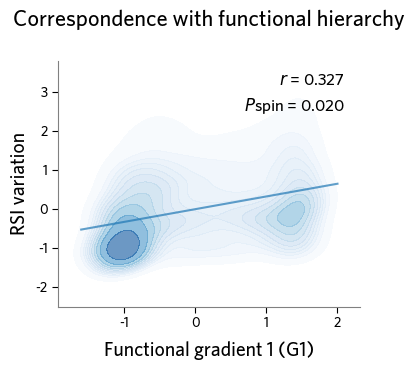

(<Figure size 380x380 with 1 Axes>,
 <Axes: title={'center': 'Correspondence with functional hierarchy'}, xlabel='Functional gradient 1 (G1)', ylabel='RSI variation'>)

In [15]:
plot_density_with_regression(
    grad1_zs, group_var_zs,
    r_gradient, p_gradient,
    x_label='Functional gradient 1 (G1)',
    y_label='RSI variation',
    title='Correspondence with functional hierarchy',
    cmap='Blues',
    line_color='#1F77B4',
    ylim=(-2.5, 3.8),
    line_xlim=(-1.6, 2),
    kde_alpha=0.6,
    kde_levels=12,
    line_alpha=0.7,
)

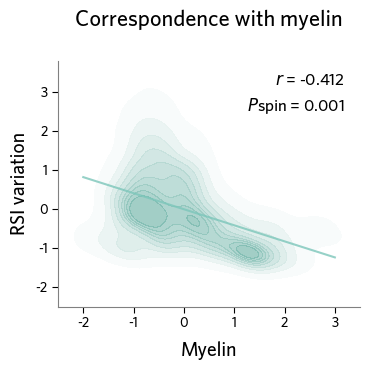

(<Figure size 380x380 with 1 Axes>,
 <Axes: title={'center': 'Correspondence with myelin'}, xlabel='Myelin', ylabel='RSI variation'>)

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.colors as mcolors

def create_professional_cmap(base_color_hex):

    base_rgb = mcolors.hex2color(base_color_hex)

    color_list = [(1, 1, 1), base_rgb] 
    
    return mcolors.LinearSegmentedColormap.from_list('pro_greens', color_list, N=256)

myelin_cmap = create_professional_cmap('#62ada0')


plot_density_with_regression(
    myelin_zs, group_var_zs,
    r_myelin, p_myelin,
    x_label='Myelin',
    y_label='RSI variation',
    title='Correspondence with myelin',
    cmap=myelin_cmap,
    line_color='#7cc6ba',
    ylim=(-2.5, 3.8),
    xlim=(-2.5, 3.5),
    line_xlim=(-2, 3),
    kde_alpha=0.65,
    kde_levels=10,
    line_alpha=0.8,
)